In [ ]:
#1. Carga `auto_mpg.csv` y realiza el primer contacto con el dataset. Reporta dimensiones, primeras fi las,
#  tipos de datos y defi ne qué representa una fi la.
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("mpg")

In [3]:
df.shape

(398, 9)

In [4]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [6]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin              str
name                str
dtype: object

In [7]:
#2. Clasifica `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`, `model_year`, `origin` y `name`. 
# Identifica qué variables, aunque puedan verse numéricas, conviene tratar como categorías o variables temporales.

clasificacion_variables = pd.DataFrame({
    "variable": [
        "mpg",
        "cylinders",
        "displacement",
        "horsepower",
        "weight",
        "acceleration",
        "model_year",
        "origin",
        "name"
    ],
    
    "clasificacion": [
        "numerica - continua",
        "numerica - discreta",
        "numerica - continua",
        "numerica - continua",
        "numerica - continua",
        "numerica - continua",
        "categorica - ordinal",
        "categorica - nominal",
        "categorica - nominal"
    ]
})

clasificacion_variables

,variable,clasificacion
0,mpg,numerica - continua
1,cylinders,numerica - discreta
2,displacement,numerica - continua
3,horsepower,numerica - continua
4,weight,numerica - continua
5,acceleration,numerica - continua
6,model_year,categorica - ordinal
7,origin,categorica - nominal
8,name,categorica - nominal


In [10]:
#3. Analiza valores faltantes y duplicados exactos. ¿En qué variable faltan datos y qué proporción representan?

faltantes = df.isnull().sum()
proporcion_faltantes = (df.isnull().sum() / len(df)) * 100
duplicados = df.duplicated().sum()

resumen = pd.DataFrame({
    "valores_faltantes": faltantes,
    "proporcion_%": proporcion_faltantes,
    "valores_duplicados": duplicados
})

resumen

,valores_faltantes,proporcion_%,valores_duplicados
mpg,0,0.000000,0
cylinders,0,0.000000,0
displacement,0,0.000000,0
horsepower,6,1.507538,0
weight,0,0.000000,0
acceleration,0,0.000000,0
model_year,0,0.000000,0
origin,0,0.000000,0
name,0,0.000000,0


In [ ]:
#4. Estudia la cardinalidad de `name`. ¿Cuántos nombres distintos hay? ¿Que un nombre aparezca varias veces signifi ca que las fi las son duplicadas? 
# Compruébalo con ejemplos.

nombres_distintos = df["name"].nunique()
nombres_distintos

305

In [14]:
frecuencia_nombres = df["name"].value_counts()
frecuencia_nombres


name
ford pinto          6
ford maverick       5
amc matador         5
toyota corolla      5
chevrolet impala    4
                   ..
ford mustang gl     1
vw pickup           1
dodge rampage       1
ford ranger         1
chevy s-10          1
Name: count, Length: 305, dtype: int64

In [15]:
nombres_repetidos = frecuencia_nombres[frecuencia_nombres > 1]
nombres_repetidos.head(10)

name
ford pinto            6
ford maverick         5
amc matador           5
toyota corolla        5
chevrolet impala      4
amc hornet            4
peugeot 504           4
amc gremlin           4
toyota corona         4
chevrolet chevette    4
Name: count, dtype: int64

In [17]:
#5. Calcula estadísticos descriptivos de `mpg`, `weight` y `horsepower`: media, mediana, desviación estándar, cuartiles e IQR. 
# Interpreta qué te dicen sobre un automóvil “típico” y sobre la dispersión.
resumen = df[["mpg", "weight","horsepower"]].agg(["mean", "median", "std"])
resumen



,mpg,weight,horsepower
mean,23.514573,2970.424623,104.469388
median,23.000000,2803.500000,93.500000
std,7.815984,846.841774,38.491160


In [18]:
q = df[["mpg", "weight","horsepower"]].quantile([0.25, 0.75]).T
q.columns = ["q1", "q3"]
q["iqr"] = q["q3"] - q["q1"]
q

,q1,q3,iqr
mpg,17.50,29.0,11.50
weight,2223.75,3608.0,1384.25
horsepower,75.00,126.0,51.00


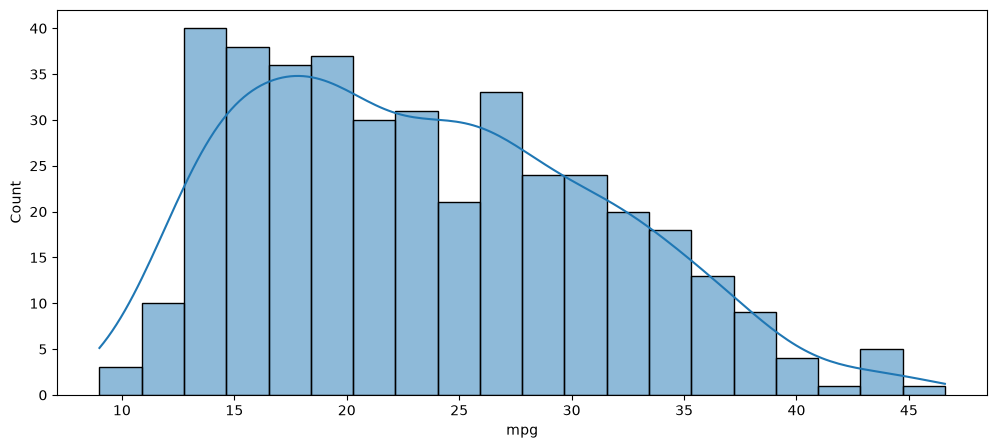

In [21]:
# 6. Analiza la distribución de `mpg` con histograma y KDE.

fig, axes = plt.subplots(figsize=(12, 5))
sns.histplot(data=df, x="mpg", bins=20, kde=True)
plt.show()

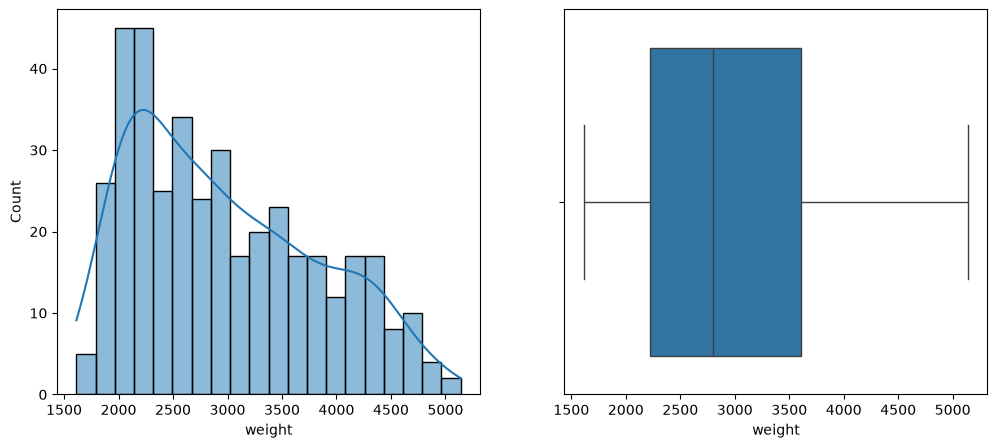

In [22]:
#7. Analiza `weight` con histograma y boxplot. ¿La distribución es simétrica? ¿Hay valores extremos según la regla del IQR? Documenta el cálculo
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=df, x="weight", bins=20, kde=True, ax=axes[0])

sns.boxplot(data=df, x="weight", ax=axes[1])

plt.show()

In [23]:
# Cálculo del IQR para weight

Q1 = df["weight"].quantile(0.25)
Q3 = df["weight"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

valores_extremos = df[
    (df["weight"] < limite_inferior) |
    (df["weight"] > limite_superior)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Cantidad de valores extremos:", len(valores_extremos))

Q1: 2223.75
Q3: 3608.0
IQR: 1384.25
Límite inferior: 147.375
Límite superior: 5684.375
Cantidad de valores extremos: 0


In [24]:
#8. Detecta outliers en `horsepower` usando 1.5·IQR. Lista los vehículos identifi cados y comenta si parecen errores evidentes 
# o automóviles de alta potencia plausibles.


horsepower = df["horsepower"].dropna()

Q1 = horsepower.quantile(0.25)
Q3 = horsepower.quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 75.0
Q3: 126.0
IQR: 51.0
Límite inferior: -1.5
Límite superior: 202.5


In [25]:
outliers_hp = df[
    (df["horsepower"] < limite_inferior) |
    (df["horsepower"] > limite_superior)
]

outliers_hp[
    ["name", "horsepower", "cylinders", "displacement", "weight", "model_year"]
].sort_values("horsepower", ascending=False)

,name,horsepower,cylinders,displacement,weight,model_year
116,pontiac grand prix,230.0,8,400.0,4278,73
8,pontiac catalina,225.0,8,455.0,4425,70
95,buick electra 225 custom,225.0,8,455.0,4951,73
13,buick estate wagon (sw),225.0,8,455.0,3086,70
6,chevrolet impala,220.0,8,454.0,4354,70
7,plymouth fury iii,215.0,8,440.0,4312,70
94,chrysler new yorker brougham,215.0,8,440.0,4735,73
25,ford f250,215.0,8,360.0,4615,70
27,dodge d200,210.0,8,318.0,4382,70
67,mercury marquis,208.0,8,429.0,4633,72


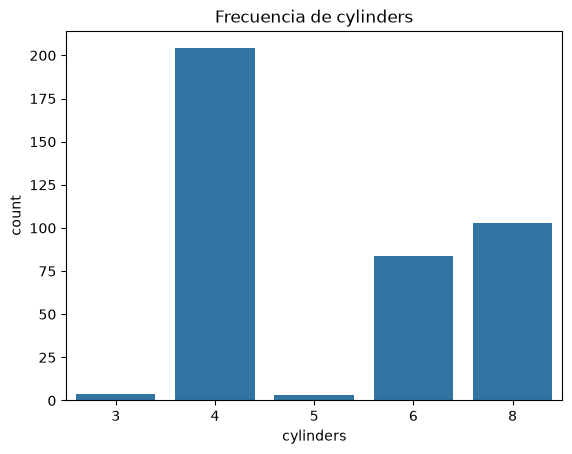

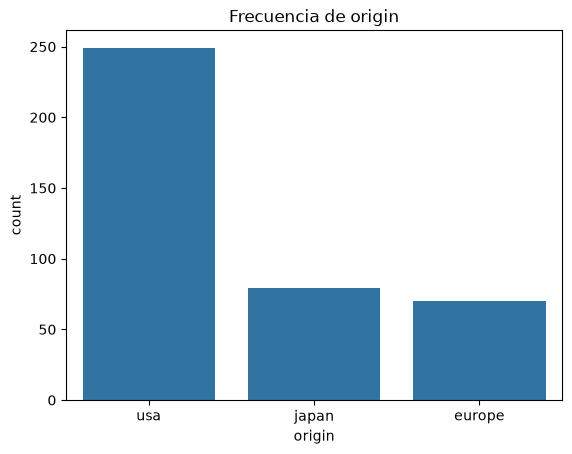

In [26]:
#9. Explora `cylinders` y `origin` mediante frecuencias y gráfi cos de barras. ¿Qué categorías dominan el dataset? ¿Hay categorías con muy pocos casos?

for col in ["cylinders", "origin"]:
    sns.countplot(data=df, x=col)
    plt.title(f"Frecuencia de {col}")
    plt.show()

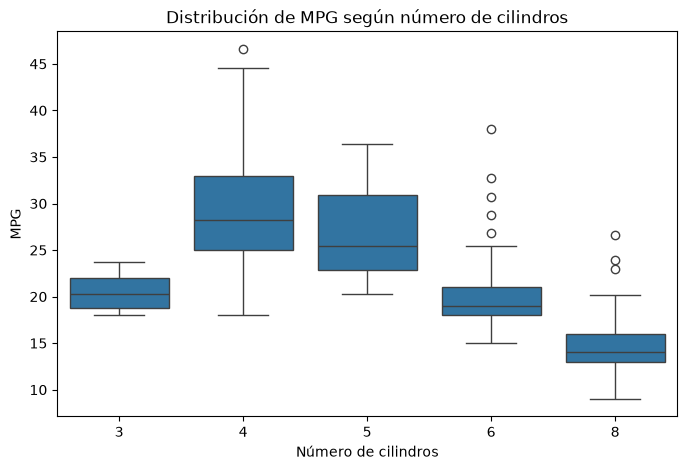

In [27]:
#10. Compara `mpg` entre vehículos con distinto número de cilindros mediante boxplot y medias/medianas por grupo. ¿Qué patrón general observas?

orden_cilindros = sorted(df["cylinders"].unique())

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="cylinders",
    y="mpg",
    order=orden_cilindros
)

plt.xlabel("Número de cilindros")
plt.ylabel("MPG")
plt.title("Distribución de MPG según número de cilindros")

plt.show()

In [28]:
resumen_cilindros = (
    df.groupby("cylinders")["mpg"]
    .agg(["mean", "median"])
    .round(2)
)

resumen_cilindros

,mean,median
cylinders,,
3,20.55,20.25
4,29.29,28.25
5,27.37,25.40
6,19.99,19.00
8,14.96,14.00


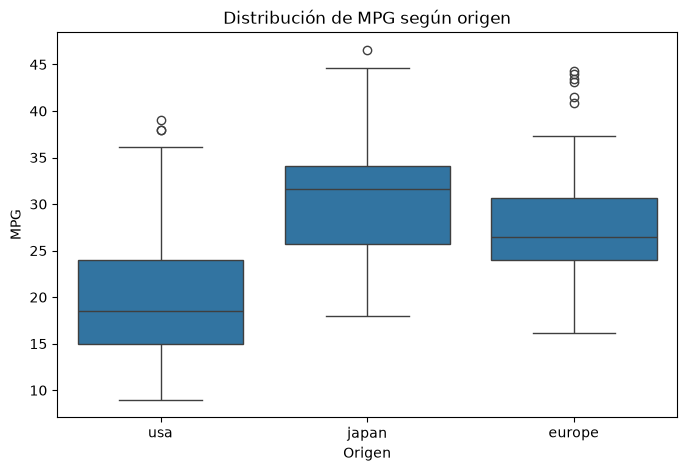

In [29]:
#11. Compara `mpg` entre los tres orígenes del dataset. Usa boxplot y estadísticas por grupo.
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="origin",
    y="mpg"
)

plt.xlabel("Origen")
plt.ylabel("MPG")
plt.title("Distribución de MPG según origen")

plt.show()

In [30]:
resumen_origen = (
    df.groupby("origin")["mpg"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)
resumen_origen

,count,mean,median,std
origin,,,,
europe,70,27.89,26.5,6.72
japan,79,30.45,31.6,6.09
usa,249,20.08,18.5,6.40


Correlación entre weight y mpg: -0.8317409332443354


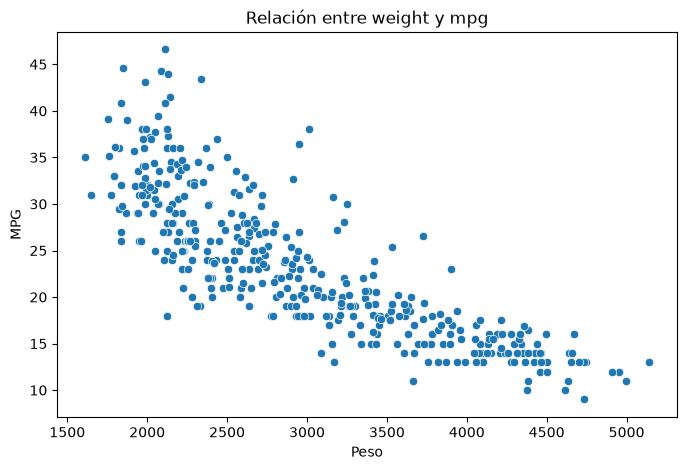

In [32]:
#12. Estudia la relación entre `weight` y `mpg` con un scatterplot y la correlación.
correlacion = df["weight"].corr(df["mpg"])
print("Correlación entre weight y mpg:", correlacion)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg"
)

plt.xlabel("Peso")
plt.ylabel("MPG")
plt.title("Relación entre weight y mpg")

plt.show()


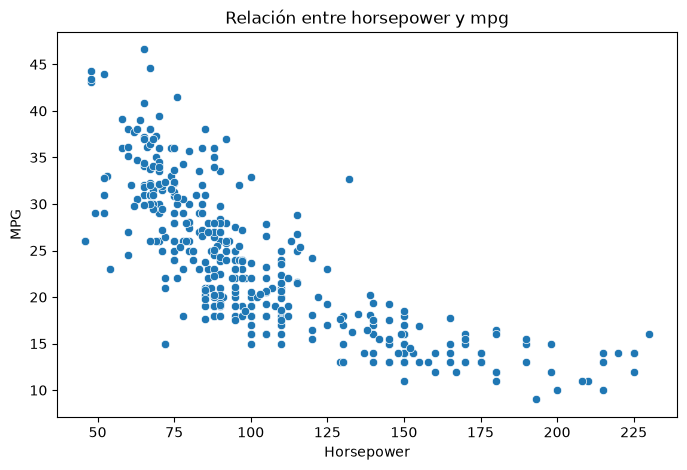

np.float64(-0.7784267838977761)

In [36]:
#13. Estudia la relación entre `horsepower` y `mpg` con scatterplot y correlación. Compara su intensidad con la relación `weight`–`mpg`
datos_hp = df[["horsepower", "mpg"]].dropna()

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=datos_hp,
    x="horsepower",
    y="mpg"
)

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Relación entre horsepower y mpg")

plt.show()
correlacion_hp = datos_hp["horsepower"].corr(datos_hp["mpg"])
correlacion_hp

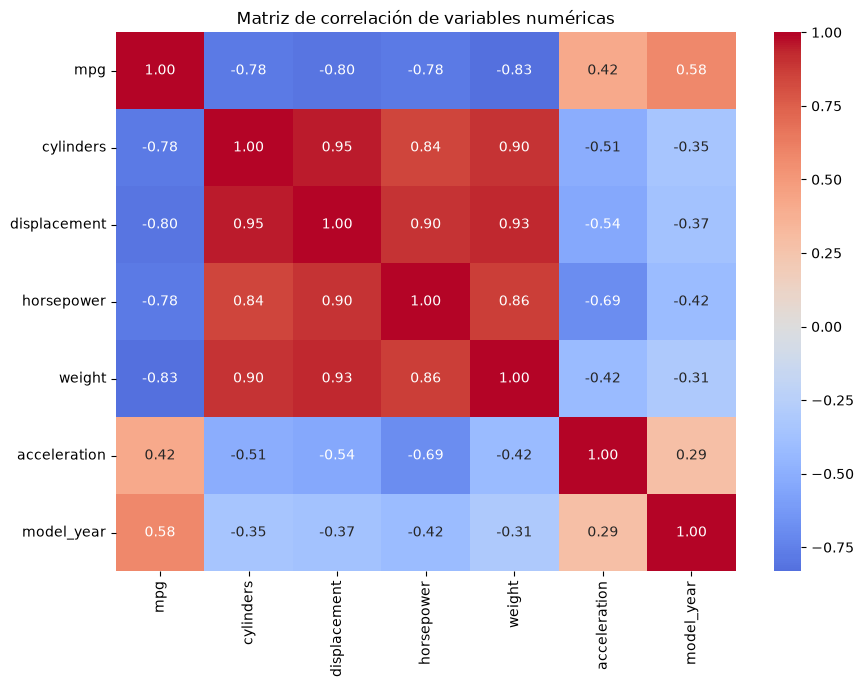

In [38]:
# 14. Construye una matriz de correlación y heatmap de las variables numéricas. Identifi ca las tres variables con mayor asociación lineal absoluta con `mpg` y 
# comenta posibles redundancias entre predictores.

variables_numericas = df.select_dtypes(include="number")
matriz_correlacion = variables_numericas.corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de variables numéricas")
plt.show()

In [39]:
correlacion_mpg = (
    matriz_correlacion["mpg"]
    .drop("mpg")
    .abs()
    .sort_values(ascending=False)
)
correlacion_mpg.head(3)

weight          0.831741
displacement    0.804203
horsepower      0.778427
Name: mpg, dtype: float64

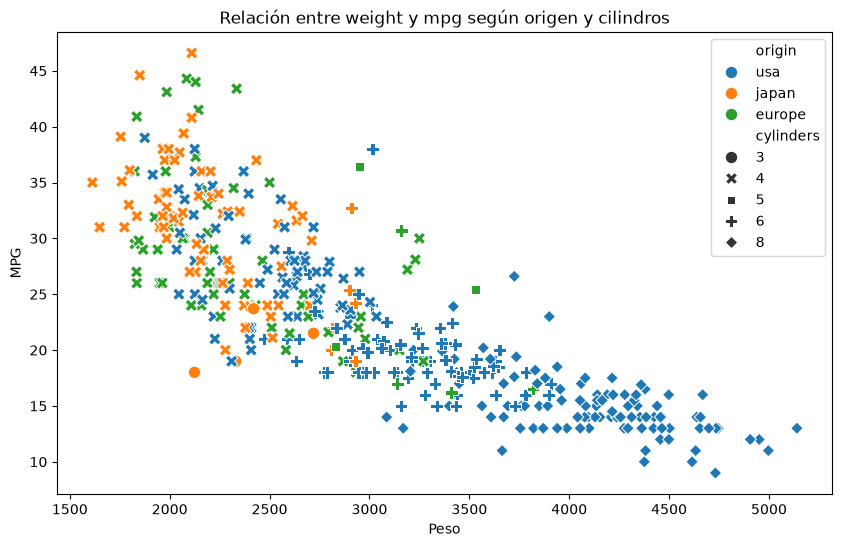

In [40]:
#15. Realiza un análisis multivariado de `weight` frente a `mpg` incorporando `origin` y `cylinders` (mediante color, estilo, facetas u otra codifi cación). 
# Añade la evolución media de `mpg` por `model_year`.
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg",
    hue="origin",
    style="cylinders",
    s=80
)

plt.xlabel("Peso")
plt.ylabel("MPG")
plt.title("Relación entre weight y mpg según origen y cilindros")

plt.show()

In [42]:
mpg_anual = (
    df.groupby(["model_year", "origin"])["mpg"]
    .mean()
    .reset_index()
)
mpg_anual.head()

,model_year,origin,mpg
0,70,europe,25.200000
1,70,japan,25.500000
2,70,usa,15.272727
3,71,europe,28.750000
4,71,japan,29.500000


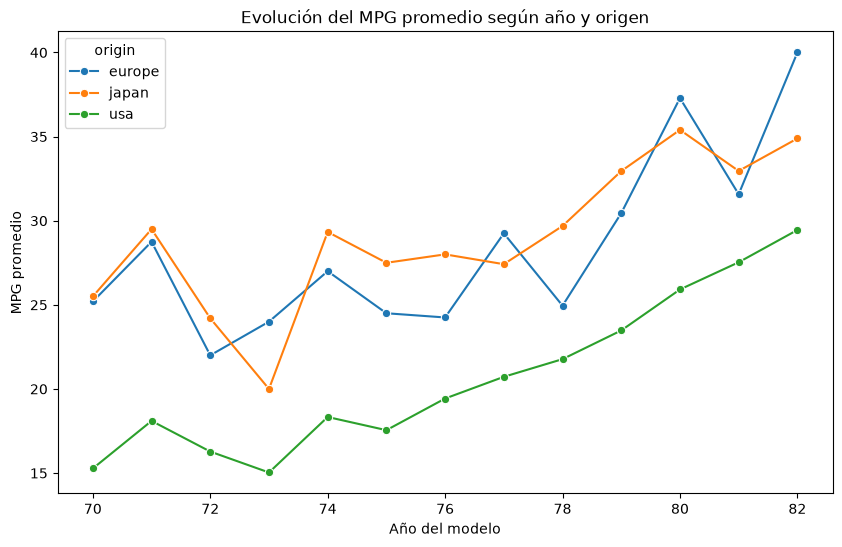

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=mpg_anual,
    x="model_year",
    y="mpg",
    hue="origin",
    marker="o"
)
plt.xlabel("Año del modelo")
plt.ylabel("MPG promedio")
plt.title("Evolución del MPG promedio según año y origen")

plt.show()

    model_year       mean  median
0           70  17.689655   16.00
1           71  21.250000   19.00
2           72  18.714286   18.50
3           73  17.100000   16.00
4           74  22.703704   24.00
5           75  20.266667   19.50
6           76  21.573529   21.00
7           77  23.375000   21.75
8           78  24.061111   20.70
9           79  25.093103   23.90
10          80  33.696552   32.70
11          81  30.334483   31.60
12          82  31.709677   32.00


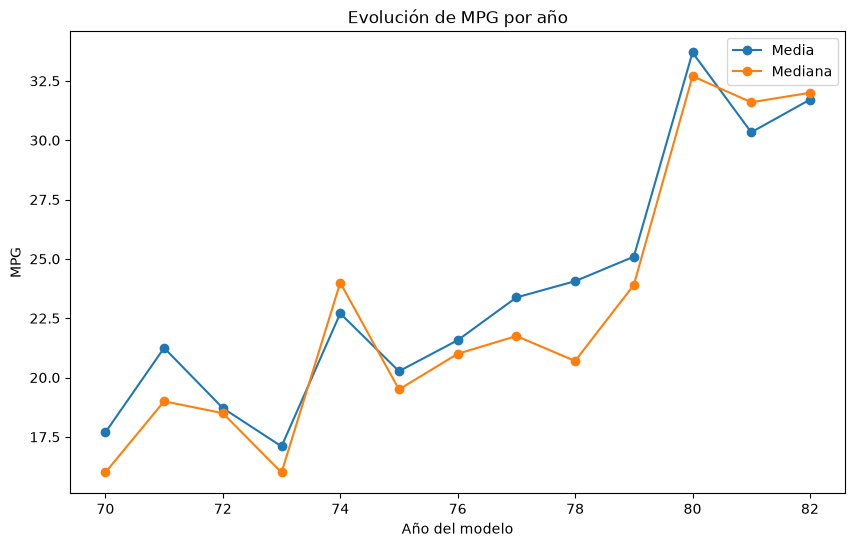

In [ ]:
# 16. Analiza la evolución de `mpg` por `model_year`. Calcula media y mediana por año y represéntalas en una gráfi ca de líneas.

resumen_anual = (
    df.groupby("model_year")["mpg"]
    .agg(["mean", "median"])
    .reset_index()
)

print(resumen_anual)
plt.figure(figsize=(10, 6))
plt.plot(
    resumen_anual["model_year"],
    resumen_anual["mean"],
    marker="o",
    label="Media"
)
plt.plot(
    resumen_anual["model_year"],
    resumen_anual["median"],
    marker="o",
    label="Mediana"
)
plt.xlabel("Año del modelo")
plt.ylabel("MPG")
plt.title("Evolución de MPG por año")
plt.legend()
plt.show()

        count     mean  median     std
origin                                
europe     70  2423.30  2240.0  490.04
japan      79  2221.23  2155.0  320.50
usa       249  3361.93  3365.0  794.79


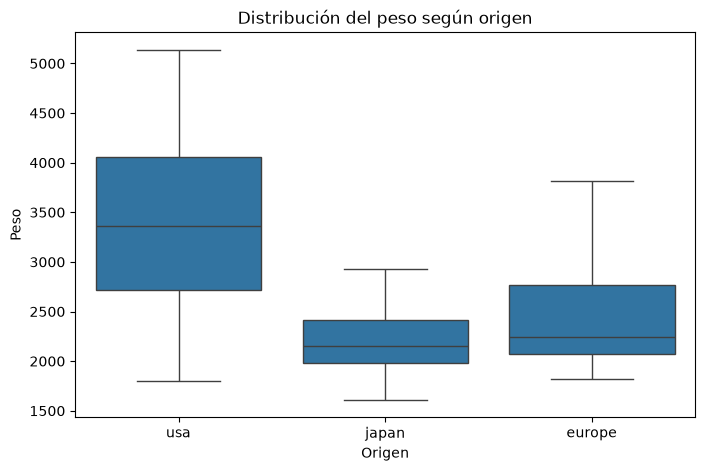

In [45]:
#17. Compara el `weight` de los automóviles por `origin` mediante estadísticas y boxplots. 
# ¿Puede la diferencia de peso ayudar a explicar parte de las diferencias de `mpg` observadas entre orígenes?
resumen_weight_origin = (
    df.groupby("origin")["weight"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print(resumen_weight_origin)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="origin",
    y="weight"
)

plt.xlabel("Origen")
plt.ylabel("Peso")
plt.title("Distribución del peso según origen")

plt.show()

In [ ]:
#18. Estudia el patrón de los valores faltantes de `horsepower`. Compara su frecuencia por `origin`, `cylinders` y `model_year`.

df["horsepower_faltante"] = df["horsepower"].isnull()

faltantes_origin = (
    df.groupby("origin")["horsepower_faltante"]
    .agg(["sum", "count", "mean"])
)

faltantes_origin["porcentaje_%"] = faltantes_origin["mean"] * 100

faltantes_cylinders = (
    df.groupby("cylinders")["horsepower_faltante"]
    .agg(["sum", "count", "mean"])
)

faltantes_cylinders["porcentaje_%"] = faltantes_cylinders["mean"] * 100

faltantes_year = (
    df.groupby("model_year")["horsepower_faltante"]
    .agg(["sum", "count", "mean"])
)

faltantes_year["porcentaje_%"] = faltantes_year["mean"] * 100

print("Faltantes por origen:")
display(faltantes_origin[["sum", "count", "porcentaje_%"]].round(2))

print("Faltantes por número de cilindros:")
display(faltantes_cylinders[["sum", "count", "porcentaje_%"]].round(2))

print("Faltantes por año del modelo:")
display(faltantes_year[["sum", "count", "porcentaje_%"]].round(2))



Faltantes por origen:


,sum,count,porcentaje_%
origin,,,
europe,2,70,2.86
japan,0,79,0.00
usa,4,249,1.61


Faltantes por número de cilindros:


,sum,count,porcentaje_%
cylinders,,,
3,0,4,0.00
4,5,204,2.45
5,0,3,0.00
6,1,84,1.19
8,0,103,0.00


Faltantes por año del modelo:


,sum,count,porcentaje_%
model_year,,,
70,0,29,0.00
71,1,28,3.57
72,0,28,0.00
73,0,40,0.00
74,1,27,3.70
75,0,30,0.00
76,0,34,0.00
77,0,28,0.00
78,0,36,0.00


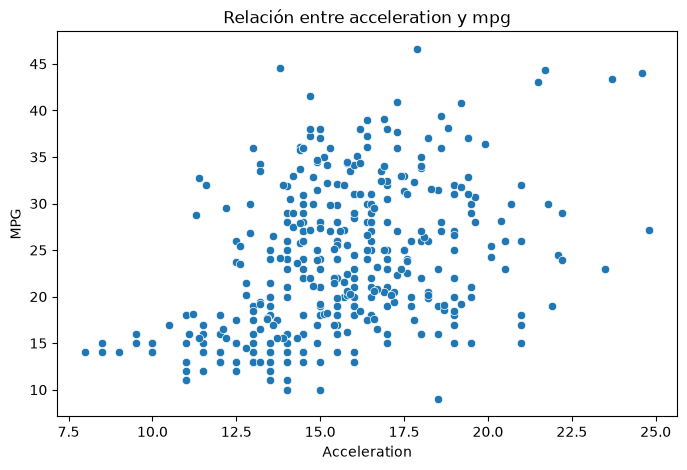

Correlación acceleration - mpg: 0.42
Correlación weight - mpg: -0.83
Correlación horsepower - mpg: -0.78


In [48]:
# 19. Analiza la relación entre `acceleration` y `mpg` mediante scatterplot y correlación de Pearson. Compara su fuerza con las relaciones de `weight`
#  y `horsepower` con `mpg`.

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="acceleration",
    y="mpg"
)

plt.xlabel("Acceleration")
plt.ylabel("MPG")
plt.title("Relación entre acceleration y mpg")

plt.show()


corr_acceleration = df["acceleration"].corr(df["mpg"])

corr_weight = df["weight"].corr(df["mpg"])

corr_horsepower = (
    df[["horsepower", "mpg"]]
    .dropna()
    .corr()
    .loc["horsepower", "mpg"]
)

print("Correlación acceleration - mpg:", round(corr_acceleration, 2))
print("Correlación weight - mpg:", round(corr_weight, 2))
print("Correlación horsepower - mpg:", round(corr_horsepower, 2))

Matriz de correlación:


,displacement,horsepower,weight
displacement,1.00,0.90,0.93
horsepower,0.90,1.00,0.86
weight,0.93,0.86,1.00


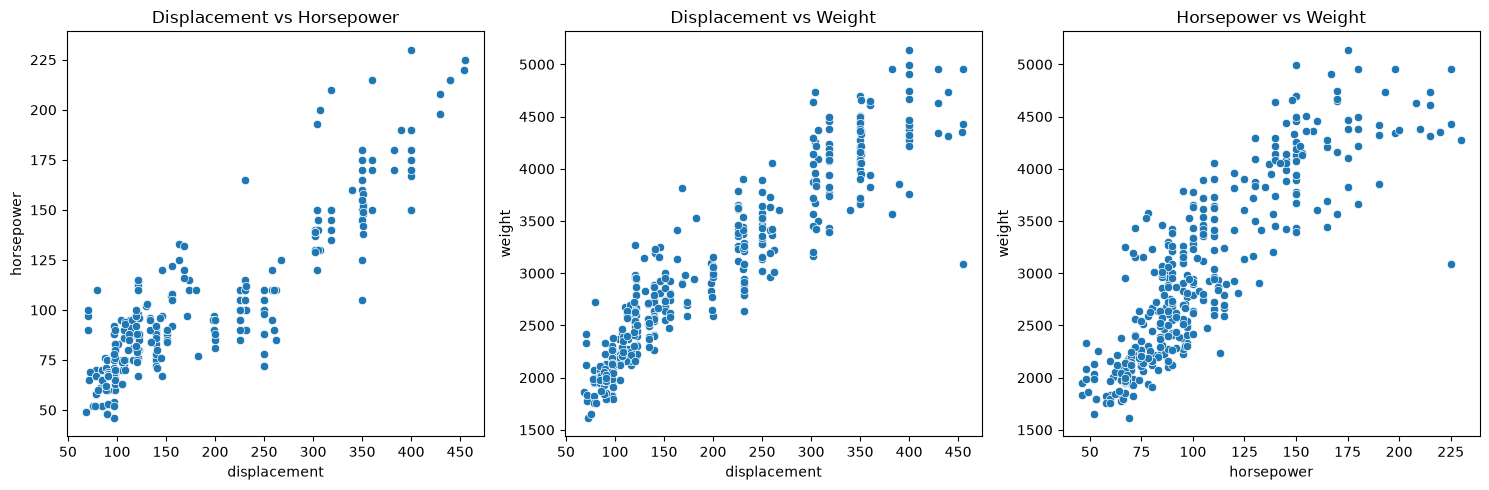

In [49]:
#20. Explora las relaciones entre `displacement`, `horsepower` y `weight`. Calcula sus correlaciones y crea gráfi cos de dispersión.
#  ¿Qué problema podría aparecer si se usan simultáneamente como predictores sin revisar redundancias?

variables = df[["displacement", "horsepower", "weight"]].dropna()

correlaciones = variables.corr()

print("Matriz de correlación:")
display(correlaciones.round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(
    data=variables,
    x="displacement",
    y="horsepower",
    ax=axes[0]
)

sns.scatterplot(
    data=variables,
    x="displacement",
    y="weight",
    ax=axes[1]
)

sns.scatterplot(
    data=variables,
    x="horsepower",
    y="weight",
    ax=axes[2]
)

axes[0].set_title("Displacement vs Horsepower")
axes[1].set_title("Displacement vs Weight")
axes[2].set_title("Horsepower vs Weight")

plt.tight_layout()
plt.show()

In [51]:
#21. Construye una tabla pivote con el `mpg` medio por `cylinders` y `origin`, incluyendo el número de automóviles por grupo. 
# ¿El patrón de cilindros se mantiene dentro de cada origen? Señala grupos con muestras pequeñas.

tabla_pivote = pd.pivot_table(
    df,
    values="mpg",
    index="cylinders",
    columns="origin",
    aggfunc=["mean", "count"]
)

tabla_pivote.round(2)

mean                count             
origin    europe  japan    usa europe japan    usa
cylinders                                         
3            NaN  20.55    NaN    NaN   4.0    NaN
4          28.41  31.60  27.84   63.0  69.0   72.0
5          27.37    NaN    NaN    3.0   NaN    NaN
6          20.10  23.88  19.66    4.0   6.0   74.0
8            NaN    NaN  14.96    NaN   NaN  103.0

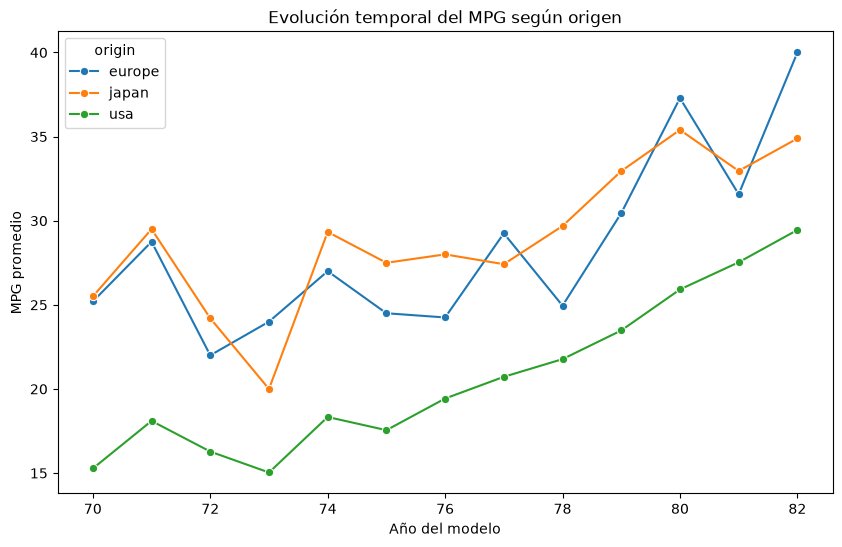

In [53]:
#22. Compara la evolución temporal de `mpg` entre `origin` usando líneas por grupo. ¿Los tres orígenes mejoran con el tiempo?
#  ¿La brecha entre orígenes permanece constante?

mpg_origen_anual = (
    df.groupby(["model_year", "origin"])["mpg"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=mpg_origen_anual,
    x="model_year",
    y="mpg",
    hue="origin",
    marker="o"
)

plt.xlabel("Año del modelo")
plt.ylabel("MPG promedio")
plt.title("Evolución temporal del MPG según origen")

plt.show()

In [ ]:
# 23. Compara los outliers de `horsepower` detectados mediante 1.5·IQR y mediante |z| > 3. 
# Lista los vehículos más extremos y explica por qué un método puede ser más estricto que el otro en una distribución asimétrica.
datos_hp = df.dropna(subset=["horsepower"]).copy()
Q1 = datos_hp["horsepower"].quantile(0.25)
Q3 = datos_hp["horsepower"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_iqr = datos_hp[
    (datos_hp["horsepower"] < limite_inferior) |
    (datos_hp["horsepower"] > limite_superior)
]

media = datos_hp["horsepower"].mean()
desviacion = datos_hp["horsepower"].std(ddof=0)

datos_hp["z_score"] = (
    (datos_hp["horsepower"] - media) / desviacion
)

outliers_z = datos_hp[
    datos_hp["z_score"].abs() > 3
]

indices_comunes = outliers_iqr.index.intersection(outliers_z.index)
outliers_comunes = datos_hp.loc[indices_comunes]


print("Límite superior IQR:", round(limite_superior, 2))
print("Cantidad de outliers por IQR:", len(outliers_iqr))
print("Cantidad de outliers por Z-score:", len(outliers_z))
print("Cantidad detectada por ambos métodos:", len(outliers_comunes))

print("\nOutliers según IQR:")
display(
    outliers_iqr[
        ["name", "horsepower", "cylinders", "weight"]
    ].sort_values("horsepower", ascending=False)
)


print("\nOutliers según Z-score:")
display(
    outliers_z[
        ["name", "horsepower", "z_score"]
    ].sort_values("horsepower", ascending=False)
)


Límite superior IQR: 202.5
Cantidad de outliers por IQR: 10
Cantidad de outliers por Z-score: 5
Cantidad detectada por ambos métodos: 5

Outliers según IQR:


,name,horsepower,cylinders,weight
116,pontiac grand prix,230.0,8,4278
8,pontiac catalina,225.0,8,4425
95,buick electra 225 custom,225.0,8,4951
13,buick estate wagon (sw),225.0,8,3086
6,chevrolet impala,220.0,8,4354
7,plymouth fury iii,215.0,8,4312
94,chrysler new yorker brougham,215.0,8,4735
25,ford f250,215.0,8,4615
27,dodge d200,210.0,8,4382
67,mercury marquis,208.0,8,4633



Outliers según Z-score:


,name,horsepower,z_score
116,pontiac grand prix,230.0,3.265452
13,buick estate wagon (sw),225.0,3.135386
8,pontiac catalina,225.0,3.135386
95,buick electra 225 custom,225.0,3.135386
6,chevrolet impala,220.0,3.005320


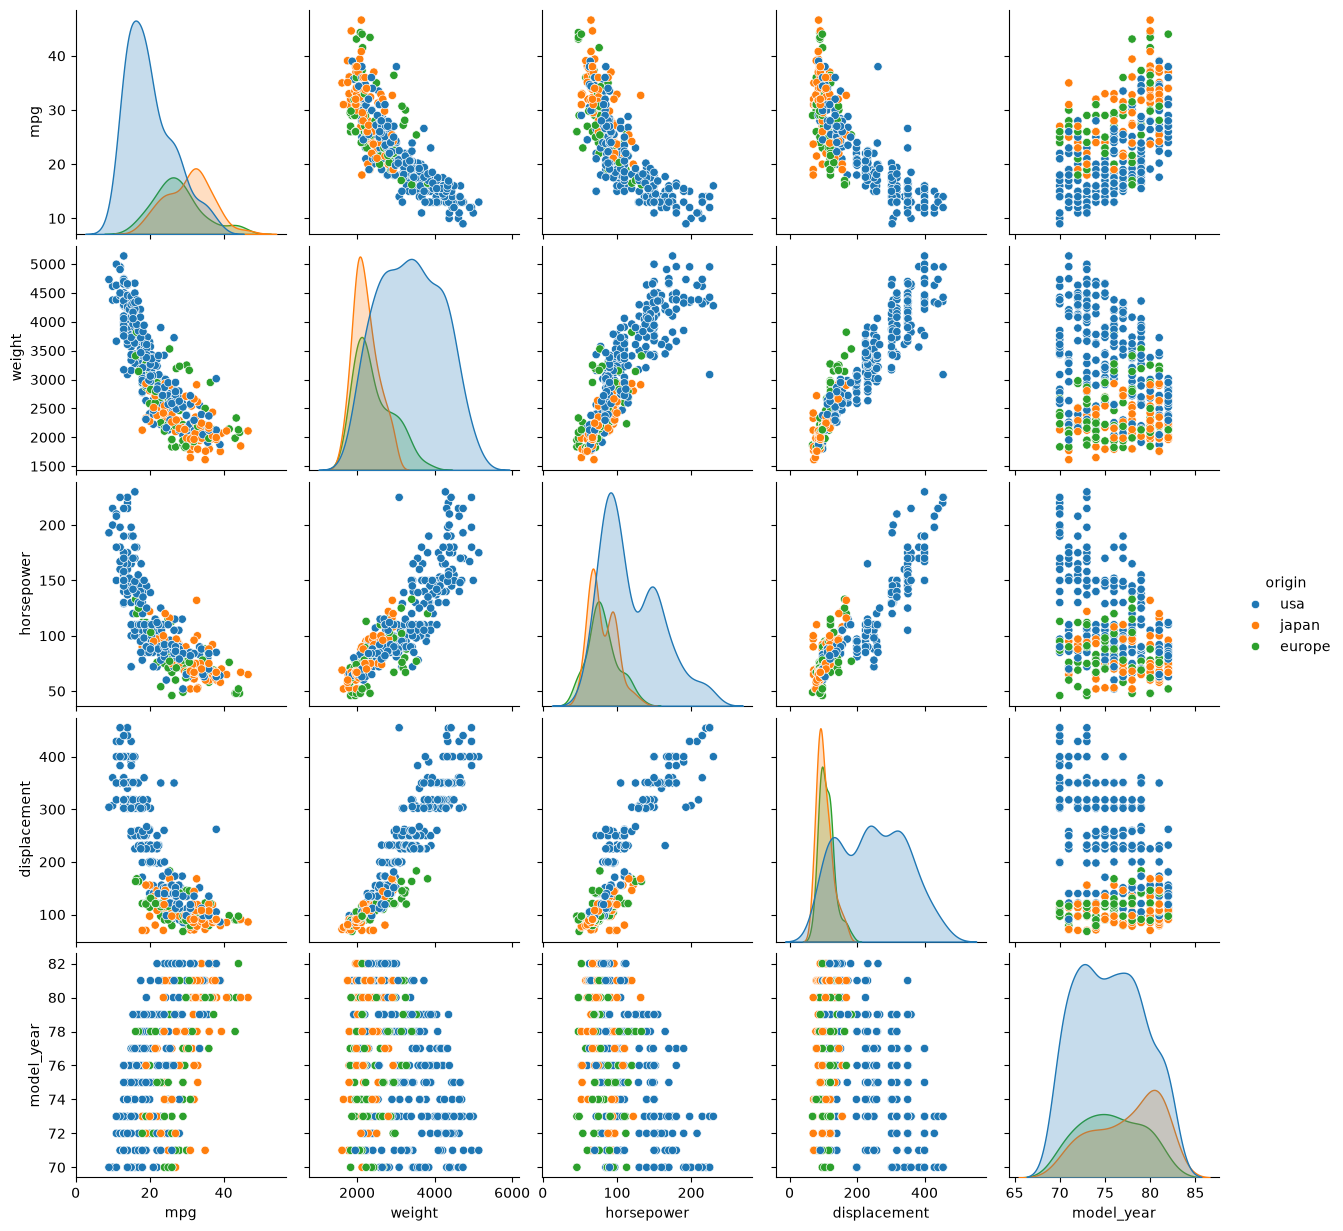

In [59]:
# 24. Construye un `pairplot` con `mpg`, `weight`, `horsepower`, `displacement` y `model_year`, usando `origin` como color.

columnas_pair = ['mpg', 'weight', 'horsepower', 'displacement', 'model_year', 'origin']
sns.pairplot(df[columnas_pair].dropna(), hue='origin')
plt.show()

In [58]:
#25. Elabora un “registro de decisiones” para preparar un análisis posterior: decide qué harías con los nulos de `horsepower`, `name`, `origin`,
#  los outliers de potencia y las variables altamente correlacionadas.


registro_decisiones = pd.DataFrame({
    "elemento": [
        "Nulos en horsepower",
        "name",
        "origin",
        "Outliers de horsepower",
        "Variables altamente correlacionadas"
    ],
    
    "decision_EDA": [
        "Mantener los registros y excluir nulos solo en análisis que usen horsepower",
        "Mantener para identificar e interpretar vehículos",
        "Mantener como variable categórica nominal",
        "Mantener, ya que corresponden a vehículos de alta potencia plausibles",
        "Mantener todas para estudiar sus relaciones"
    ],
    
    "decision_modelado": [
        "Imputar los valores faltantes o eliminar únicamente esas pocas filas",
        "No usar directamente como predictor por su alta cardinalidad",
        "Codificar mediante variables dummy / one-hot encoding",
        "No eliminar automáticamente; evaluar su influencia en el modelo",
        "Evaluar multicolinealidad y seleccionar variables o aplicar regularización"
    ]
})

registro_decisiones

,elemento,decision_EDA,decision_modelado
0,Nulos en horsepower,Mantener los registros y excluir nulos solo en...,Imputar los valores faltantes o eliminar única...
1,name,Mantener para identificar e interpretar vehículos,No usar directamente como predictor por su alt...
2,origin,Mantener como variable categórica nominal,Codificar mediante variables dummy / one-hot e...
3,Outliers de horsepower,"Mantener, ya que corresponden a vehículos de a...",No eliminar automáticamente; evaluar su influe...
4,Variables altamente correlacionadas,Mantener todas para estudiar sus relaciones,Evaluar multicolinealidad y seleccionar variab...
